In [1]:
import os
import warnings
import pandas as pd
import features2 as f
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import statistics
warnings.filterwarnings('ignore')

In [2]:
parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\CombinedClean.csv")
embeddings = pd.read_csv(parent+"\\semantics\\fasttext-static_words.csv")

similarity = pd.read_csv(parent+"\\semantics\\fasttext-static_similarity.csv")
similarity.set_index("Unnamed: 0", inplace=True)
similarity.index.name = None

categories = pd.read_csv(parent+"\\semantics\\fasttext-EmbeddingClusters.csv")

f.set_embedding_space(similarity = similarity, embeddings = embeddings)

In [3]:
data["Hit"] = data["Hit"].replace(2, 0)
df = f.apply_join(df_main =data.copy(), function = f.find_most_similiar,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.avg_sim_previous, n = 2,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.contrast,
            groupby_groups=["Participant ID", "Participant Group", "ListID"], 
            n = 3)
df = f.apply_join(df_main=df.copy(), function = f.sim_last_word,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.position_zone,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])

Mean for Group 1 : 0.325 | Mean for Group 0 : 0.330
Std for Group 1 : 0.080 | Std for Group 0 : 0.080

Mean for Group 1 : 0.328 | Mean for Group 0 : 0.332
Std for Group 1 : 0.062 | Std for Group 0 : 0.063

Mean for Group 1 : 0.330 | Mean for Group 0 : 0.331
Std for Group 1 : 0.056 | Std for Group 0 : 0.057

Mean for Group 1 : 0.329 | Mean for Group 0 : 0.332
Std for Group 1 : 0.054 | Std for Group 0 : 0.056



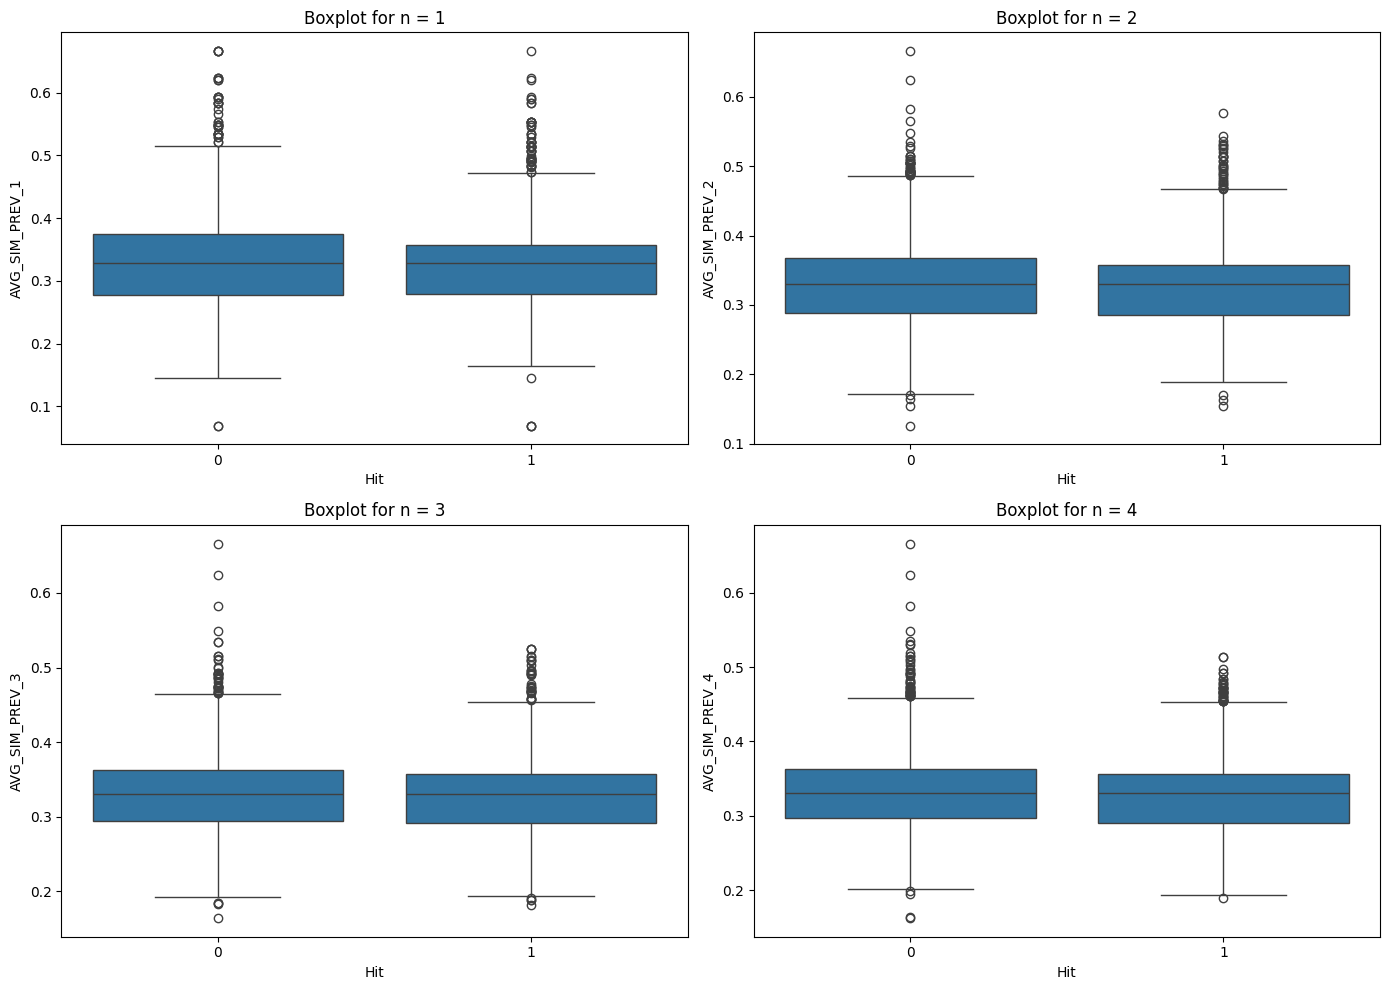

In [4]:
#n tuning for avg_sim_prev function
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  

for i in range(4):
    n = i+1
    tune_n_custom = f.apply_join(
        df_main=data.copy(), 
        function=f.avg_sim_previous, 
        n=n,
        groupby_groups=["Participant ID", "Participant Group", "ListID"]
    )
    
    col_name = f"AVG_SIM_PREV_{n}"
    tune_n_custom[col_name].fillna(tune_n_custom[col_name].mean(), inplace=True)
    
    sns.boxplot(data=tune_n_custom, x="Hit", y=col_name, ax=axes[i])
    axes[i].set_title(f"Boxplot for n = {n}")

    mean1 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    mean0 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    sd1 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    sd0 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    print(f"Mean for Group 1 : {mean1:.3f} | Mean for Group 0 : {mean0:.3f}")
    print(f"Std for Group 1 : {sd1:.3f} | Std for Group 0 : {sd0:.3f}\n")

plt.tight_layout()
plt.show()

In [5]:
df = df[df["ListID"]!=0]
df = df.drop(["Recalled Word", "Recall Position","Reaction Time","DEBUG_MOST_SIM_POS"], axis = 1)
df["P_ID"] = df["Participant Group"].astype(str)+df["Participant ID"].astype(str)
df = df.drop(["Participant ID"], axis = 1)
df.columns = [col.upper() for col in df.columns]
df.columns = [col.replace(" ", "_") for col in df.columns]
df.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_3,PREV_SIM,PRESENT_ZONE,P_ID
6,1,KALEM,1,1,soc,NaN,NaN,NaN,0.525725,NaN,1,soc9
7,1,ÖLÇEK,2,0,soc,0.338901,1.0,0.338901,0.557002,0.338901,1,soc9
8,1,ÇANTA,3,0,soc,0.352932,2.0,0.297480,0.532265,0.242028,1,soc9
9,1,AĞAÇ,4,1,soc,0.383445,2.0,0.382491,0.407015,0.381538,1,soc9
10,1,PARK,5,0,soc,0.428213,1.0,0.385916,0.520172,0.428213,2,soc9


<Axes: ylabel='Count'>

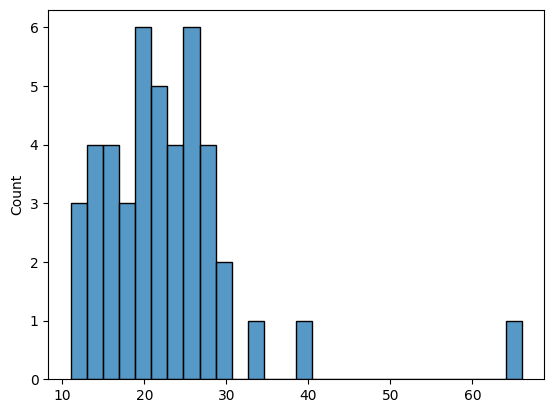

In [6]:
participant_hits = df.groupby(by="P_ID")["HIT"].apply(sum)
sns.histplot(participant_hits.values, binwidth=2)

In [7]:
#df.to_csv(parent+"\\data\\MEM_Features_01.csv")

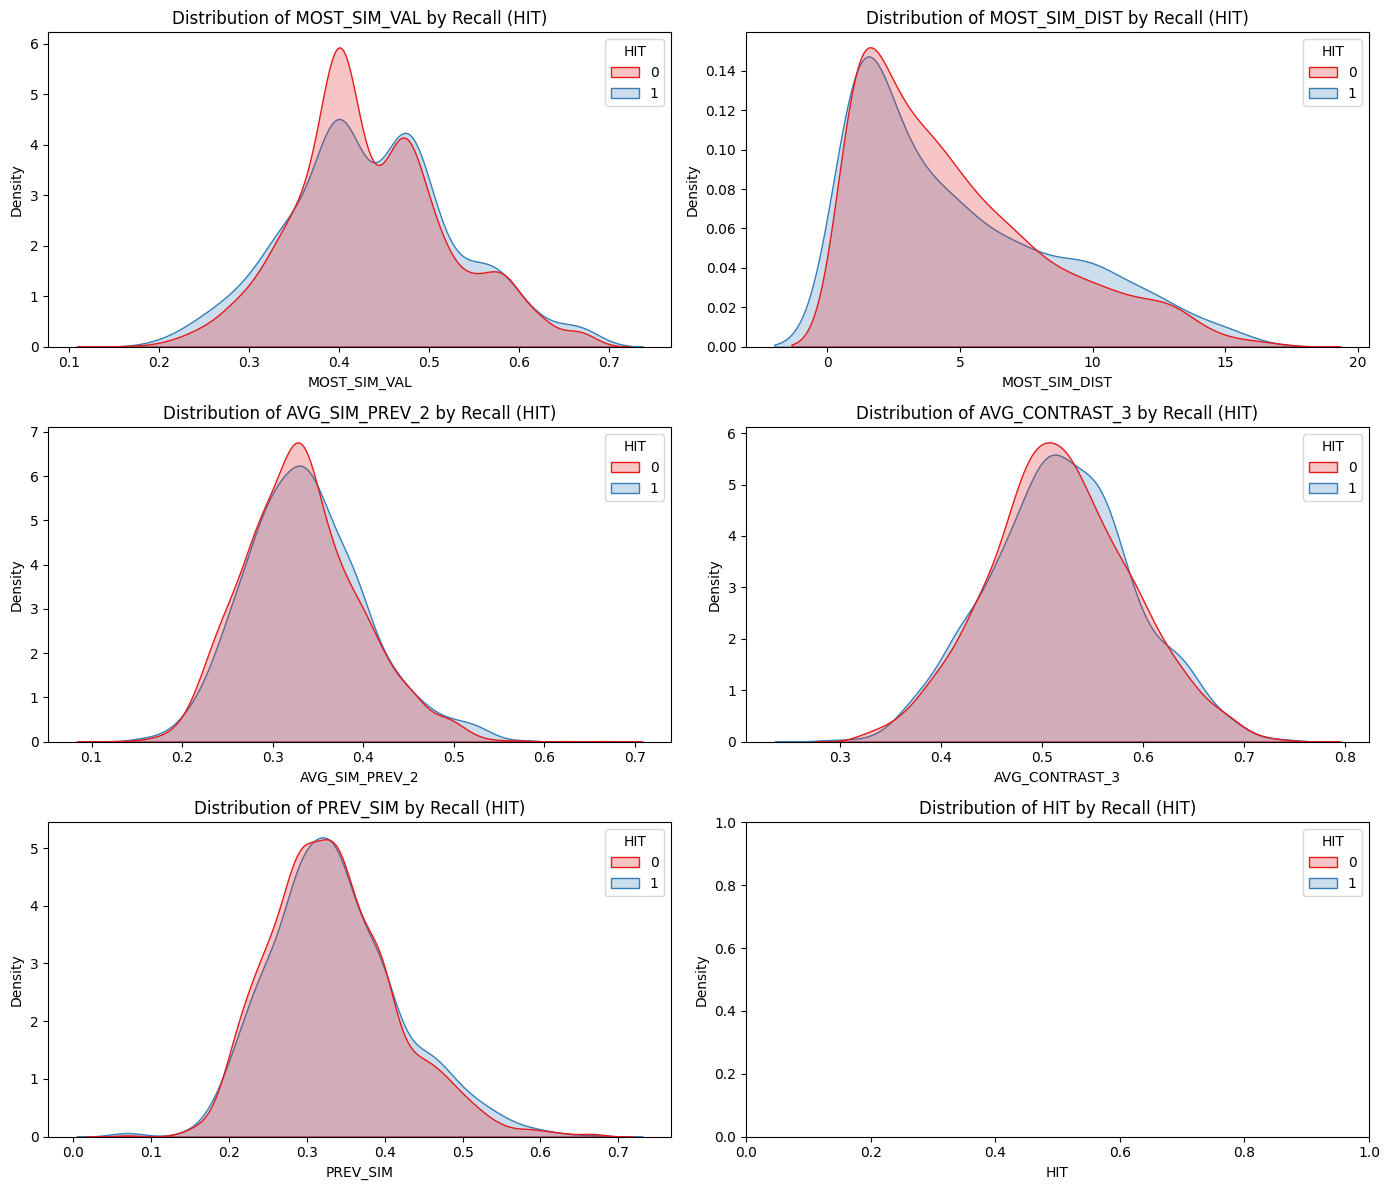

In [8]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()
features_to_plot = ["MOST_SIM_VAL", "MOST_SIM_DIST", "AVG_SIM_PREV_2","AVG_CONTRAST_3","PREV_SIM", "HIT"]
for i, feature in enumerate(features_to_plot):
    # sns.kdeplot normalizes the density, making the 70/30 imbalance irrelevant visually
    sns.kdeplot(data=df, x=feature, hue="HIT", common_norm=False, fill=True, ax=axes[i], palette="Set1")
    axes[i].set_title(f"Distribution of {feature} by Recall (HIT)")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

## Transforming Similarities

<Axes: xlabel='MASA', ylabel='Density'>

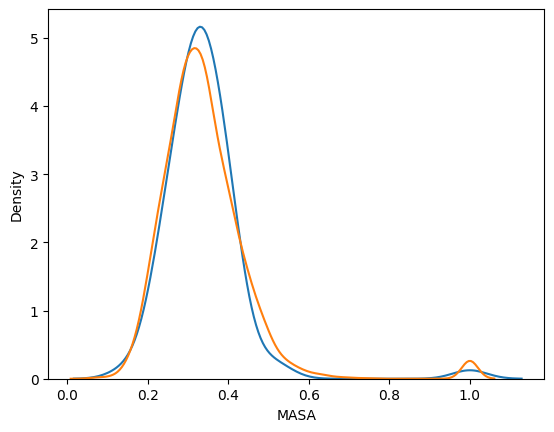

In [9]:
sns.kdeplot(similarity["MASA"])
sns.kdeplot(similarity.values.flatten().tolist())

In [10]:
import plotly.express as px
mask = np.triu(np.ones(similarity.shape), k=1).astype(bool)
upper_tri = similarity.where(mask)

# 2. Flatten into a 1D DataFrame and drop the empty (NaN) values
pairs = upper_tri.unstack().reset_index()
pairs.columns = ['Word 1', 'Word 2', 'Similarity']
pairs = pairs.dropna()

# 3. Create an interactive strip plot (jitter plot)
fig = px.strip(
    pairs, 
    x="Similarity", 
    hover_data=["Word 1", "Word 2"],
    title="Distribution of Pairwise Similarities",
    stripmode="overlay"
)

# 4. Display the interactive plot
fig.show()

<Axes: >

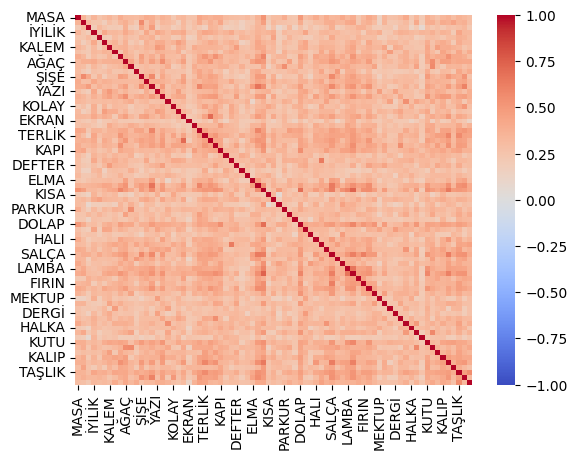

In [11]:
sns.heatmap(similarity, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)


In [12]:
print(similarity["AĞAÇ"][similarity["AĞAÇ"]>.45])

AĞAÇ      1.000000
BARDAK    0.467670
KAĞIT     0.548642
KÖPEK     0.462025
KEDİ      0.514439
ELMA      0.454965
KAŞIK     0.527949
SEHPA     0.496251
TOPRAK    0.459042
SALÇA     0.511026
ÇİÇEK     0.464292
DÜĞME     0.453003
TAHTA     0.483345
BAHÇE     0.556055
KALIP     0.471521
ÇORAP     0.465073
Name: AĞAÇ, dtype: float64


Alpha: 6.0, Beta: 9.0


<Axes: >

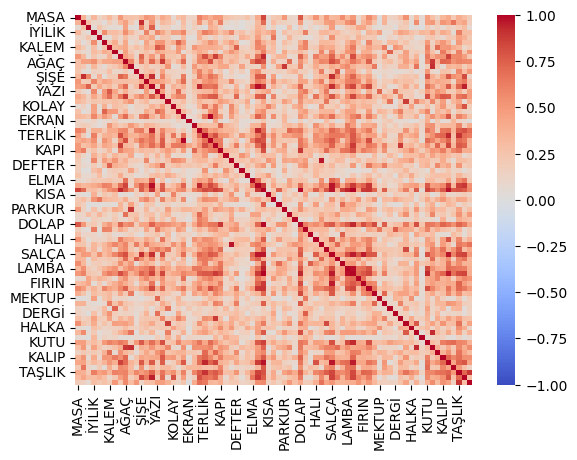

In [13]:
target_mean = 0.4

# 2. Choose your concentration (higher = steeper stretch)
k = 15

# 3. Calculate exact alpha and beta 
alpha_param = target_mean * k
beta_param = (1 - target_mean) * k

# alpha_param = 10
# beta_param = 15

target_mean = 0.45


print(f"Alpha: {alpha_param}, Beta: {beta_param}")

from scipy.stats import beta
transformed_similarities = similarity.copy()
for col in similarity.columns: 
    transformed_similarities[col] = beta.cdf(similarity[col], a=alpha_param, b=beta_param)

sns.heatmap(transformed_similarities, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)



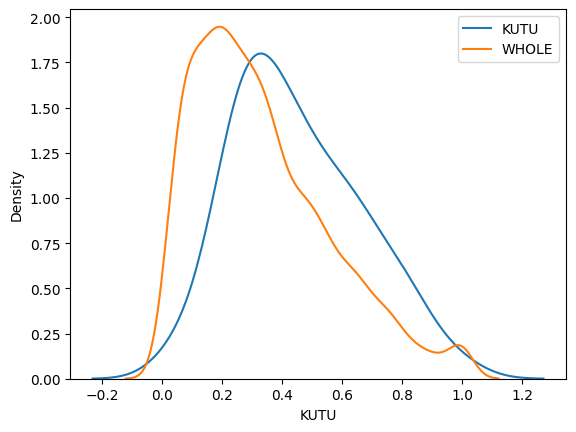

In [14]:
sns.kdeplot(transformed_similarities["KUTU"], label="KUTU")
sns.kdeplot(transformed_similarities.values.flatten().tolist(), label="WHOLE")
plt.legend()

<Axes: ylabel='Density'>

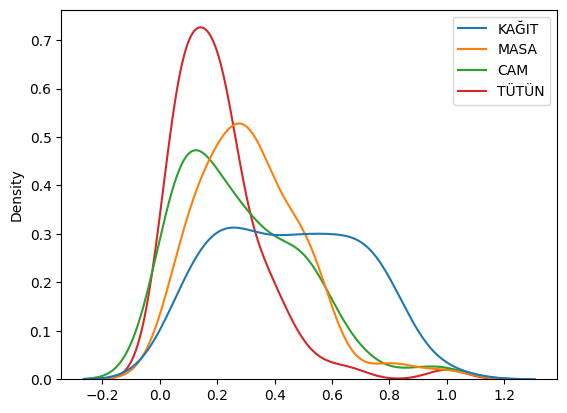

In [15]:
sns.kdeplot(transformed_similarities[["KAĞIT","MASA","CAM","TÜTÜN"]])

<Axes: ylabel='Density'>

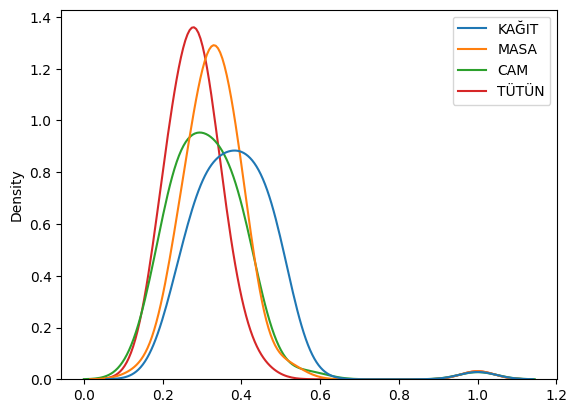

In [16]:
sns.kdeplot(similarity[["KAĞIT","MASA","CAM","TÜTÜN"]])

In [17]:
parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\CombinedClean.csv")
embeddings = pd.read_csv(parent+"\\semantics\\fasttext-static_words.csv")

similarity = pd.read_csv(parent+"\\semantics\\fasttext-static_similarity.csv")
similarity.set_index("Unnamed: 0", inplace=True)
similarity.index.name = None

f.set_embedding_space(similarity = transformed_similarities, embeddings = embeddings)
data["Hit"] = data["Hit"].replace(2, 0)
df = f.apply_join(df_main =data.copy(), function = f.find_most_similiar,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.avg_sim_previous, n = 1,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.contrast,
            groupby_groups=["Participant ID", "Participant Group", "ListID"], 
            n = 1)
df = f.apply_join(df_main=df.copy(), function=f.avg_sim_previous, n = 5,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function=f.contrast,
            groupby_groups=["Participant ID", "Participant Group", "ListID"], 
            n = 5)
df = f.apply_join(df_main=df.copy(), function = f.sim_last_word,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.ft_stm_cumulative_semantic_density, n= 4,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])
df = f.apply_join(df_main=df.copy(), function = f.ft_stm_max_sim_n, n= 4,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
df = f.apply_join(df_main=df.copy(), function = f.stm_uniqueness, n= 4,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function

df = f.apply_join(df_main=df.copy(), function = f.position_zone,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function

df = f.apply_join(df_main=df.copy(), function = f.categories_in_zone, n= 4, categories_df = categories,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
df = f.apply_join(df_main=df.copy(), function = f.categories_in_zone_count, n= 4, categories_df = categories,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
df = f.apply_join(df_main=df.copy(), function = f.category_in_stm_n, n= 4, categories_df = categories,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
df = f.apply_join(df_main=df.copy(), function = f.category_in_stm_n, n= 1, categories_df = categories,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
df = f.apply_join(df_main=df.copy(), function = f.category_fetch_clusters, n= 1, categories_df = categories,
             groupby_groups=["Participant ID", "Participant Group", "ListID"])#n tuning for avg_sim_prev function
"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  

for i in range(4):
    n = i+1
    tune_n_custom = f.apply_join(
        df_main=data.copy(), 
        function=f.avg_sim_previous, 
        n=n,
        groupby_groups=["Participant ID", "Participant Group", "ListID"]
    )
    
    col_name = f"AVG_SIM_PREV_{n}"
    tune_n_custom[col_name].fillna(tune_n_custom[col_name].mean(), inplace=True)
    
    sns.boxplot(data=tune_n_custom, x="Hit", y=col_name, ax=axes[i])
    axes[i].set_title(f"Boxplot for n = {n}")

    mean1 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    mean0 = np.mean(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    sd1 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==1])
    sd0 = statistics.stdev(tune_n_custom[col_name][tune_n_custom["Hit"]==0])
    print(f"Mean for Group 1 : {mean1:.3f} | Mean for Group 0 : {mean0:.3f}")
    print(f"Std for Group 1 : {sd1:.3f} | Std for Group 0 : {sd0:.3f}\n")

plt.tight_layout()
plt.show()
"""

df = df[df["ListID"]!=0]
df = df.drop(["Recalled Word", "Recall Position","Reaction Time","DEBUG_MOST_SIM_POS"], axis = 1)
df["P_ID"] = df["Participant Group"].astype(str)+df["Participant ID"].astype(str)
df = df.drop(["Participant ID"], axis = 1)
df.columns = [col.upper() for col in df.columns]
df.columns = [col.replace(" ", "_") for col in df.columns]
df.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_1,AVG_CONTRAST_1,AVG_SIM_PREV_5,...,SAME_CLUSTER_IN_Z1,SAME_CLUSTER_IN_Z2,SAME_CLUSTER_IN_Z3,SAME_CLUSTER_IN_Z1_COUNT,SAME_CLUSTER_IN_Z2_COUNT,SAME_CLUSTER_IN_Z3_COUNT,CATEGORY_IN_STM_4,CATEGORY_IN_STM_1,CLUSTER,P_ID
6,1,KALEM,1,1,soc,NaN,NaN,NaN,0.661099,NaN,...,1,0,1,1,0,2,0,0,8,soc9
7,1,ÖLÇEK,2,0,soc,0.326431,1.0,0.326431,0.643500,0.326431,...,1,0,1,1,0,1,0,0,1,soc9
8,1,ÇANTA,3,0,soc,0.368361,2.0,0.098149,0.616813,0.233255,...,1,0,0,1,0,0,0,0,5,soc9
9,1,AĞAÇ,4,1,soc,0.462612,2.0,0.456668,0.504513,0.449454,...,1,0,1,1,0,1,0,0,9,soc9
10,1,PARK,5,0,soc,0.599958,1.0,0.599958,0.589818,0.338558,...,0,1,1,0,1,1,0,0,3,soc9


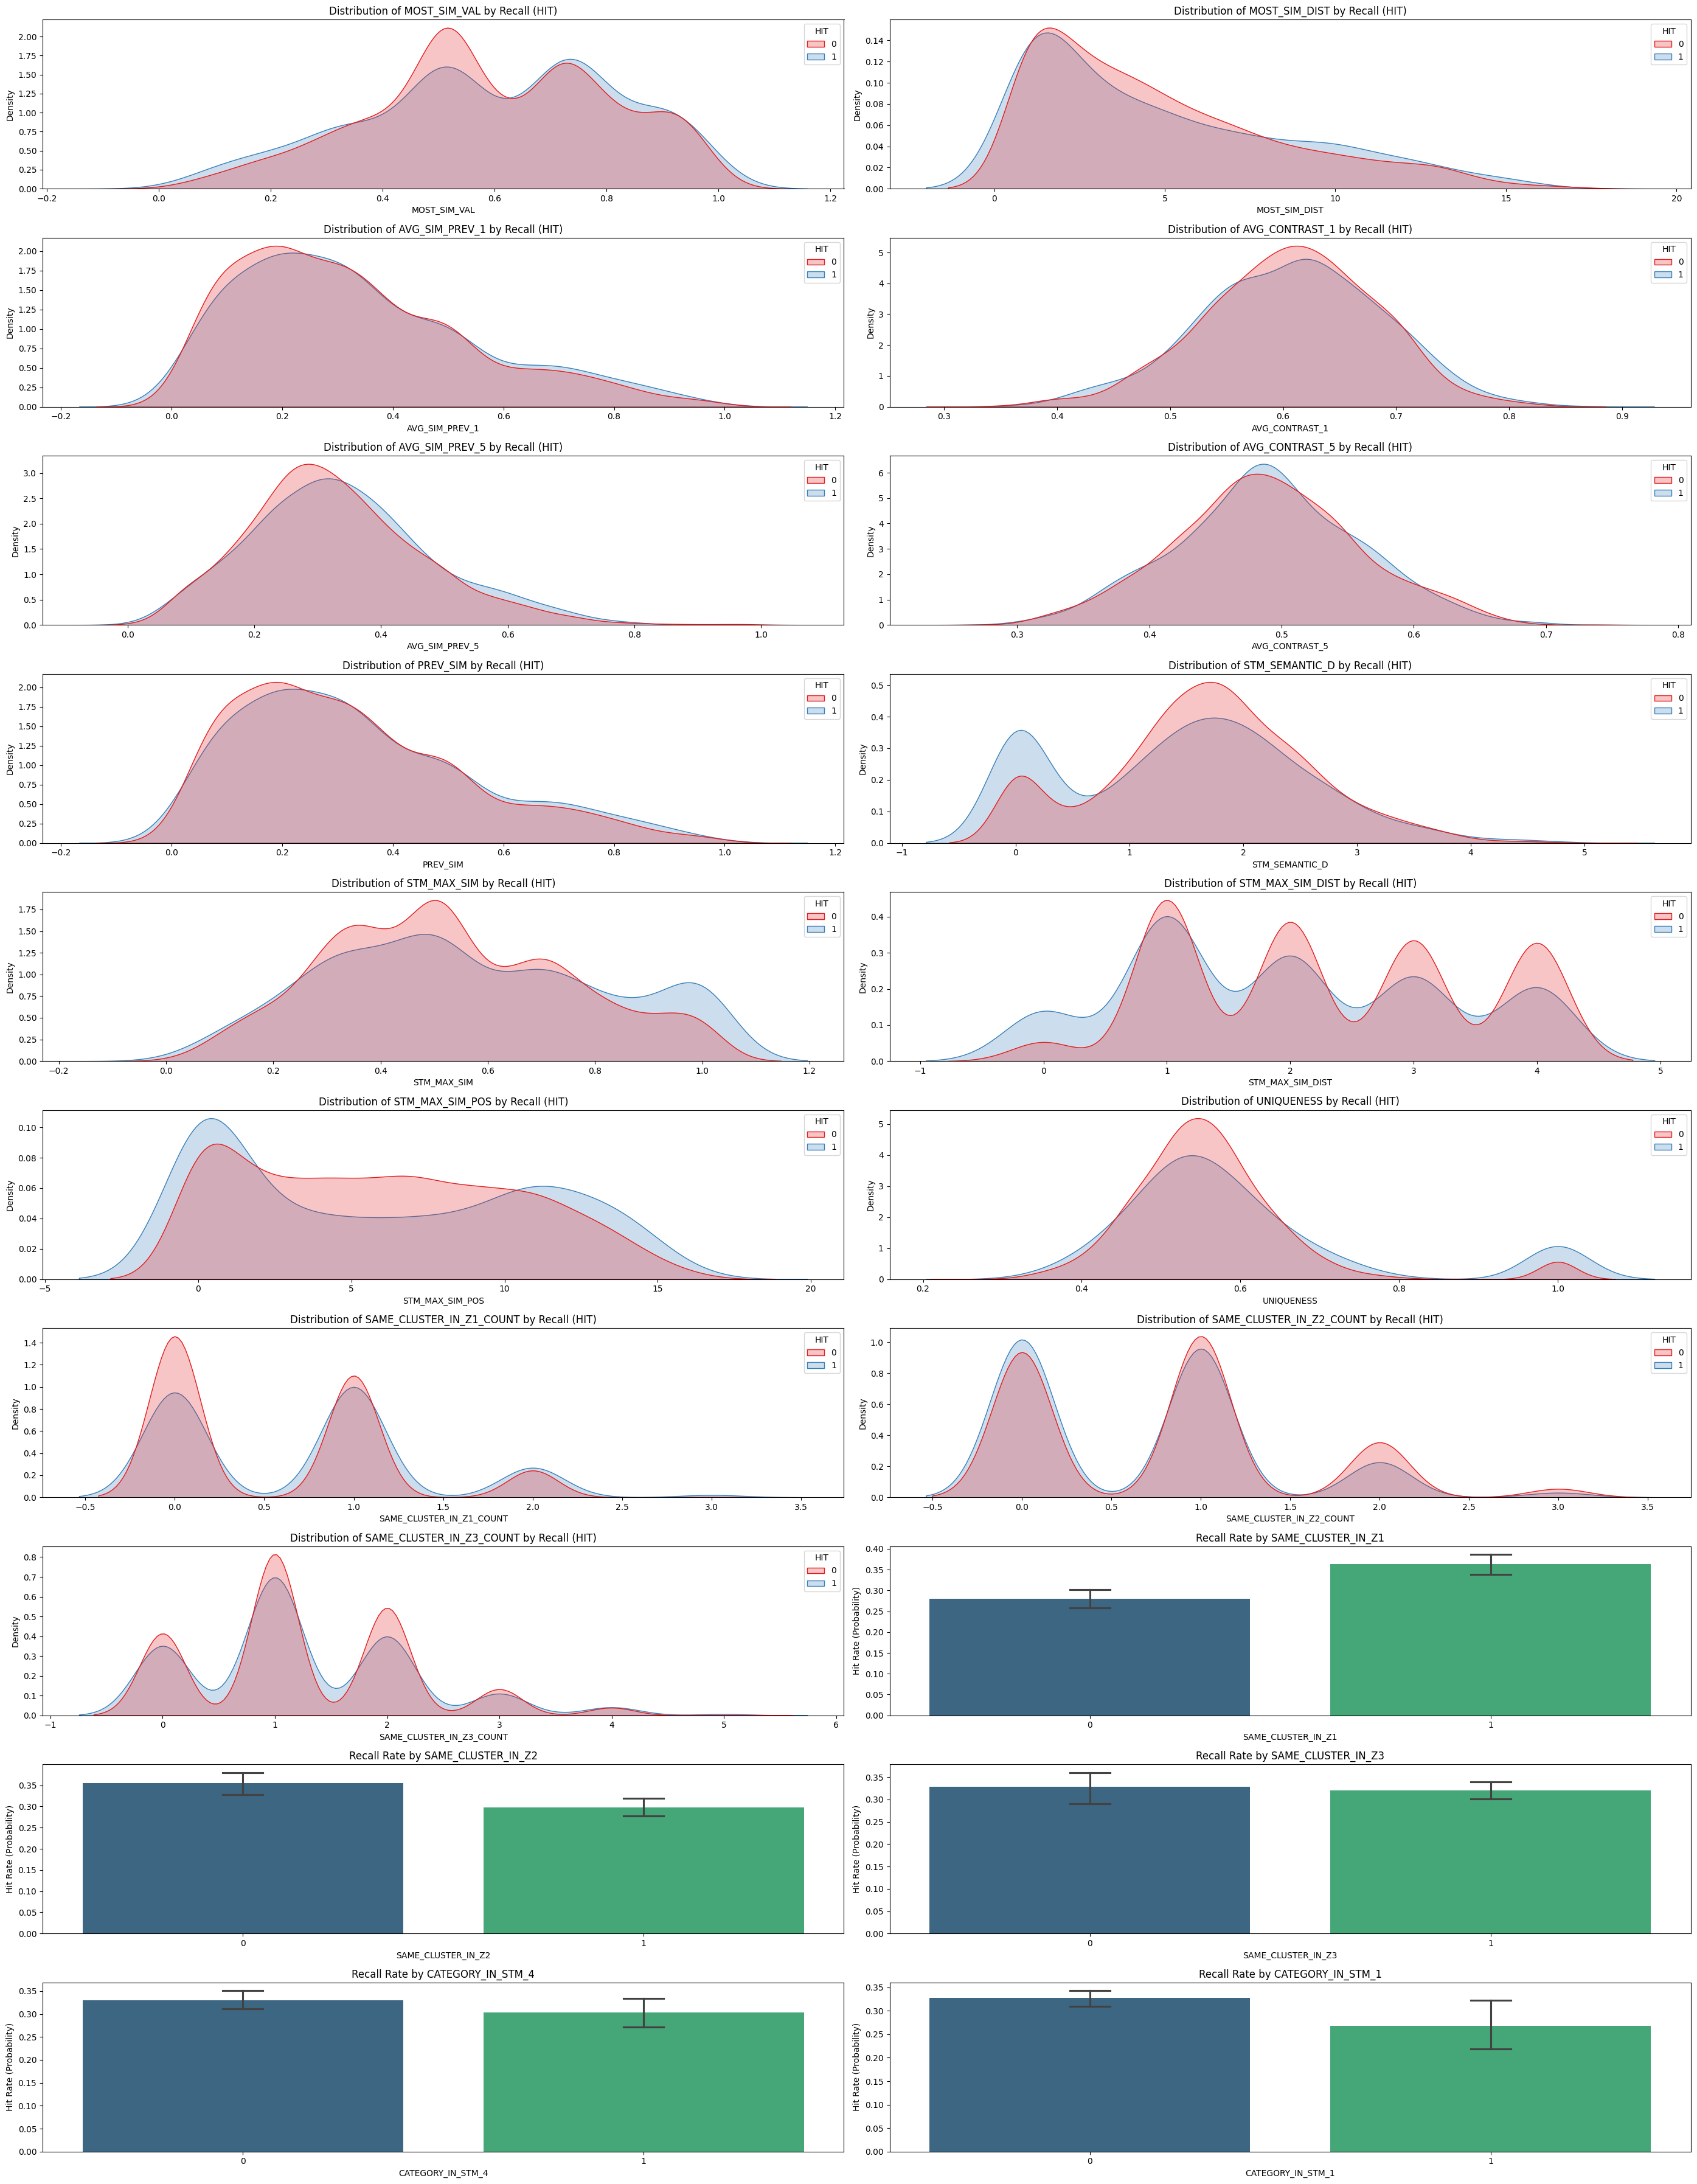

In [18]:
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(28, 36))
axes = axes.flatten()

features_to_plot = [
    "MOST_SIM_VAL", "MOST_SIM_DIST", "AVG_SIM_PREV_1", "AVG_CONTRAST_1",
    "AVG_SIM_PREV_5", "AVG_CONTRAST_5", "PREV_SIM", "STM_SEMANTIC_D", 
    "STM_MAX_SIM", "STM_MAX_SIM_DIST", "STM_MAX_SIM_POS", "UNIQUENESS", 
    "SAME_CLUSTER_IN_Z1_COUNT", "SAME_CLUSTER_IN_Z2_COUNT", "SAME_CLUSTER_IN_Z3_COUNT"
]

# 1. İlk 15 eksene (0'dan 14'e kadar) KDE grafiklerini basıyoruz
for i, feature in enumerate(features_to_plot):
    sns.kdeplot(data=df, x=feature, hue="HIT", common_norm=False, fill=True, ax=axes[i], palette="Set1")
    axes[i].set_title(f"Distribution of {feature} by Recall (HIT)")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

# 2. Bar plot için ayırdığın categorical feature'lar
bar_features = [
    'SAME_CLUSTER_IN_Z1', 
    'SAME_CLUSTER_IN_Z2', 
    'SAME_CLUSTER_IN_Z3', 
    'CATEGORY_IN_STM_4',
    'CATEGORY_IN_STM_1'
]

# 3. Bar grafikleri, KDE'lerin bittiği yerden (axes[15]'ten itibaren) basıyoruz
for j, bar_feat in enumerate(bar_features):
    ax_idx = len(features_to_plot) + j  # 15, 16, 17, 18. eksenler
    sns.barplot(data=df, x=bar_feat, y='HIT', palette='viridis', capsize=0.1, ax=axes[ax_idx])
    axes[ax_idx].set_title(f"Recall Rate by {bar_feat}")
    axes[ax_idx].set_xlabel(bar_feat)
    axes[ax_idx].set_ylabel("Hit Rate (Probability)")

# 4. Boşta kalan (kullanılmayan) eksenleri kapatıyoruz ki ekranda boş beyaz kareler kalmasın
total_plotted = len(features_to_plot) + len(bar_features)
for k in range(total_plotted, len(axes)):
    axes[k].set_axis_off()

plt.tight_layout()
plt.show()

In [19]:
df.to_csv("MEM_New-Features_fastText.csv")